# Практическое занятие: Закон Ципфа и Закон Хипса

В данном практическом примере рассмотрим два фундаментальных эмпирических закона количественной лингвистики:
1. **Закон Ципфа (Zipf's Law)** — связывает частоту встречаемости слова с его рангом в частотном словаре ($f \propto 1/r$).
2. **Закон Хипса (Heaps' Law)** — описывает скорость роста словаря (количества уникальных слов) по мере увеличения объема прочитанного текста ($V = K \cdot N^\beta$).

Мы проверим выполнение этих законов на реальных англоязычных корпусах текстов и найдем их математические коэффициенты.

In [46]:
%pip install scipy jinja2 datasets torch

Note: you may need to restart the kernel to use updated packages.


In [47]:
# Импорт библиотек для анализа данных, токенизации и визуализации
import collections
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Скачивание классических корпусов литературы через NLTK
import nltk
nltk.download('gutenberg', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import gutenberg

## Проверка закона Ципфа на примере романа «Моби Дик» Германа Мелвилла

Закон Ципфа гласит, что если все слова текста отсортировать по убыванию частоты, то частота $f$ слова с рангом $r$ приближенно равна:
$$f(r) = \frac{C}{r^\alpha}$$
Где $\alpha \approx 1$. В логарифмических координатах $(\log r, \log f)$ эта зависимость должна превращаться в прямую линию со склоном $-1$.

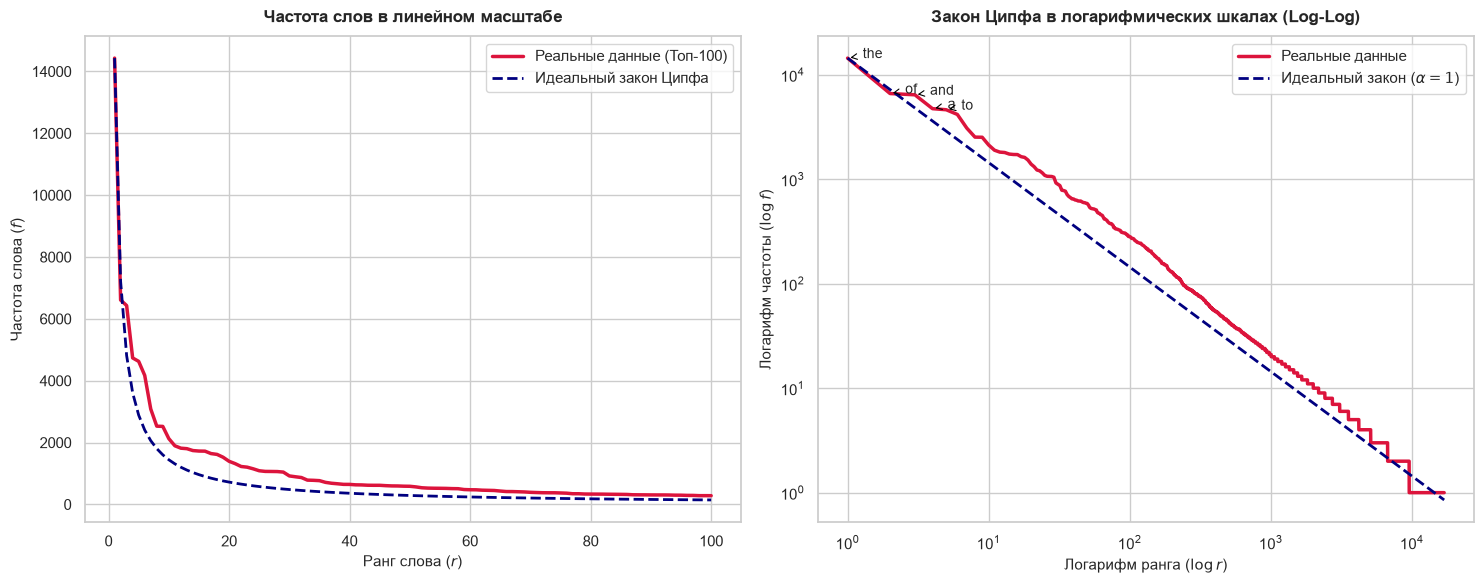

In [48]:
# Загрузка токенов романа Германа Мелвилла «Моби Дик»
moby_tokens = gutenberg.words('melville-moby_dick.txt')

# Приводим к нижнему регистру и фильтруем пунктуацию (оставляем только слова)
moby_words = [word.lower() for word in moby_tokens if word.isalpha()]

# Подсчитываем частотность каждого слова
word_counts = collections.Counter(moby_words)

# Сортируем слова по убыванию частоты для присвоения рангов
# most_common() возвращает список кортежей (слово, частота)
sorted_word_counts = word_counts.most_common()

# Формируем массивы рангов и частот
ranks = np.arange(1, len(sorted_word_counts) + 1)
frequencies = np.array([count for word, count in sorted_word_counts])

# Автоматический расчет идеальной константы Ципфа C на основе самого частого слова (ранг 1)
ideal_c = frequencies[0]
ideal_frequencies = ideal_c / ranks

# Построение графиков: в линейном и логарифмическом масштабе
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Левый график: Линейный масштаб (демонстрирует «длинный хвост» распределения)
ax1.plot(ranks[:100], frequencies[:100], color='crimson', lw=2.5, label='Реальные данные (Топ-100)')
ax1.plot(ranks[:100], ideal_frequencies[:100], color='navy', linestyle='--', lw=2, label='Идеальный закон Ципфа')
ax1.set_title('Частота слов в линейном масштабе', fontsize=12, pad=10, weight='bold')
ax1.set_xlabel('Ранг слова ($r$)', fontsize=11)
ax1.set_ylabel('Частота слова ($f$)', fontsize=11)
ax1.legend(frameon=True)

# Правый график: Логарифмический масштаб (где закон Ципфа становится прямой линией)
ax2.loglog(ranks, frequencies, color='crimson', lw=2.5, label='Реальные данные')
ax2.loglog(ranks, ideal_frequencies, color='navy', linestyle='--', lw=2, label='Идеальный закон ($\\alpha=1$)')

# Автоматически подписываем топ-5 самых частотных слов прямо на графике
for i in range(5):
    word, freq = sorted_word_counts[i]
    ax2.annotate(f" {word}", xy=(ranks[i], freq), xytext=(ranks[i]*1.2, freq),
                 arrowprops=dict(arrowstyle="->", color='black', lw=0.8), fontsize=10)

ax2.set_title('Закон Ципфа в логарифмических шкалах (Log-Log)', fontsize=12, pad=10, weight='bold')
ax2.set_xlabel('Логарифм ранга ($\log r$)', fontsize=11)
ax2.set_ylabel('Логарифм частоты ($\log f$)', fontsize=11)
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()


### Частотная таблица закона Ципфа (Топ-20 слов)

Для подтверждения закона Ципфа на практике выведем таблицу первых 20 слов. Обратите внимание на колонку **Константа (C_эмпир)**: согласно классическому закону Ципфа, произведение Ранга на Частоту ($r \cdot f$) должно оставаться относительно стабильным для высокочастотных слов.


In [49]:
import pandas as pd

# Выбираем топ-20 самых частотных слов
top_n = 20
top_words_data = sorted_word_counts[:top_n]

# Собираем данные для таблицы
table_data = {
    "Ранг (r)": range(1, top_n + 1),
    "Слово": [word for word, count in top_words_data],
    "Фактическая частота (f)": [count for word, count in top_words_data],
    "Идеальная частота": [int(ideal_frequencies[i]) for i in range(top_n)],
    "Константа (C_эмпир = r * f)": [((i + 1) * count) for i, (word, count) in enumerate(top_words_data)]
}

# Создаем DataFrame и форматируем вывод
df_zipf = pd.DataFrame(table_data)

# Настройка выравнивания и отображения таблицы в Jupyter
display(df_zipf.style.hide(axis="index")
              .set_caption("Проверка константы Ципфа для топ-20 слов романа 'Моби Дик'")
              .background_gradient(cmap="YlGnBu", subset=["Фактическая частота (f)", "Константа (C_эмпир = r * f)"])
              .format({"Фактическая частота (f)": "{:,}", "Идеальная частота": "{:,}", "Константа (C_эмпир = r * f)": "{:,}"}))


Ранг (r),Слово,Фактическая частота (f),Идеальная частота,Константа (C_эмпир = r * f)
1,the,"14,431","14,431","14,431"
2,of,"6,609","7,215","13,218"
3,and,"6,430","4,810","19,290"
4,a,"4,736","3,607","18,944"
5,to,"4,625","2,886","23,125"
6,in,"4,172","2,405","25,032"
7,that,"3,085","2,061","21,595"
8,his,"2,530","1,803","20,240"
9,it,"2,522","1,603","22,698"
10,i,"2,127","1,443","21,270"


## Закон Хипса и динамика роста словаря

Закон Хипса показывает, как растет размер словаря $V$ (количество уникальных токенов) по мере увеличения общего числа слов в тексте $N$:
$$V(N) = K \cdot N^\beta$$
Обычно параметры варьируются в диапазонах: $10 \le K \le 100$ и $0.4 \le \beta \le 0.6$. Мы построим эту кривую эмпирически, проходя по тексту «шагами».


In [50]:
# Функция для сбора точек роста словаря (размер словаря в зависимости от длины прочитанного текста)
def calculate_heaps_data(words, step=500):
    unique_words = set()
    vocabulary_sizes = []
    token_counts = []
    
    # Итерируемся по тексту с заданным шагом для экономии ресурсов
    for idx, word in enumerate(words):
        unique_words.add(word)
        if idx % step == 0 or idx == len(words) - 1:
            token_counts.append(idx + 1)
            vocabulary_sizes.append(len(unique_words))
            
    return np.array(token_counts), np.array(vocabulary_sizes)

# Собираем данные по росту словаря для «Моби Дика»
tokens_count, vocab_size = calculate_heaps_data(moby_words, step=1000)

# Математическая функция закона Хипса для аппроксимации (curve fitting)
def heaps_law_func(N, K, beta):
    return K * (N ** beta)

# Автоматически подбираем оптимальные коэффициенты K и beta методом наименьших квадратов
popt, _ = curve_fit(heaps_law_func, tokens_count, vocab_size, p0=[20, 0.5])
fitted_k, fitted_beta = popt

# Генерируем теоретические значения по закону Хипса с вычисленными коэффициентами
theoretical_vocab_size = heaps_law_func(tokens_count, fitted_k, fitted_beta)

## Визуализация закона Хипса

Выводим график роста словаря и отображаем автоматически подобранные коэффициенты $K$ и $\beta$.


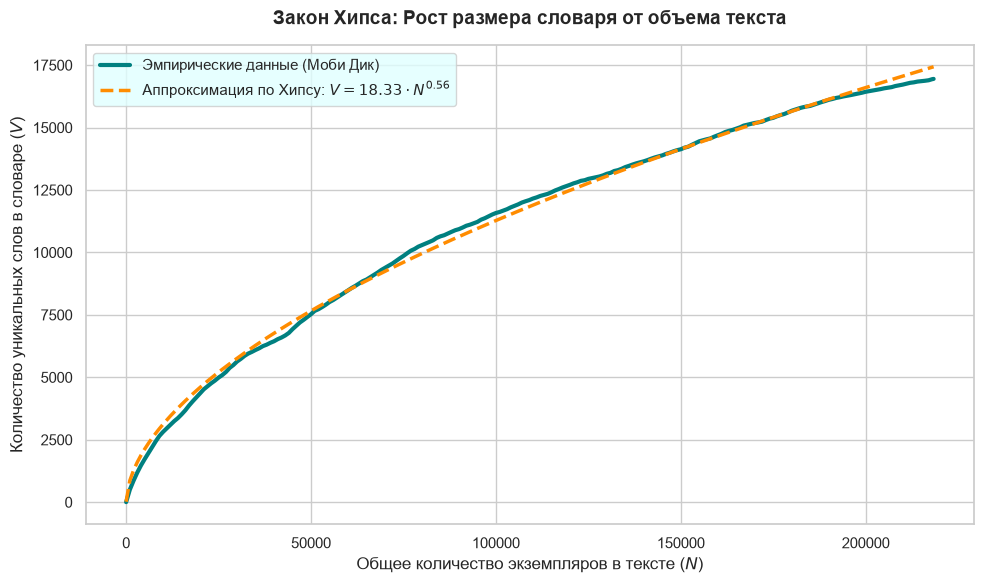

In [51]:
plt.figure(figsize=(10, 6))

# Отрисовка реальной кривой роста словаря
plt.plot(tokens_count, vocab_size, color='teal', lw=3, label='Эмпирические данные (Моби Дик)')

# Отрисовка теоретической кривой
formula_label = f'Аппроксимация по Хипсу: $V = {fitted_k:.2f} \cdot N^{{{fitted_beta:.2f}}}$'
plt.plot(tokens_count, theoretical_vocab_size, color='darkorange', linestyle='--', lw=2.5, label=formula_label)

plt.title('Закон Хипса: Рост размера словаря от объема текста', fontsize=14, pad=15, weight='bold')
plt.xlabel('Общее количество экземпляров в тексте ($N$)', fontsize=12)
plt.ylabel('Количество уникальных слов в словаре ($V$)', fontsize=12)
plt.legend(fontsize=11, frameon=True, facecolor='lightcyan')
plt.gca().ticklabel_format(style='plain', axis='x') # Отключаем экспоненциальную запись чисел по оси X

plt.tight_layout()
plt.show()


## Сравнение авторов: Трагедии Шекспира против романов Мелвилла

Закон Хипса позволяет сравнивать богатство словарного запаса разных авторов и жанров. Чем выше коэффициент $\beta$, тем быстрее автор генерирует новые уникальные слова. Сравним «Моби Дик» Мелвилла со сборником трагедий Уильяма Шекспира.

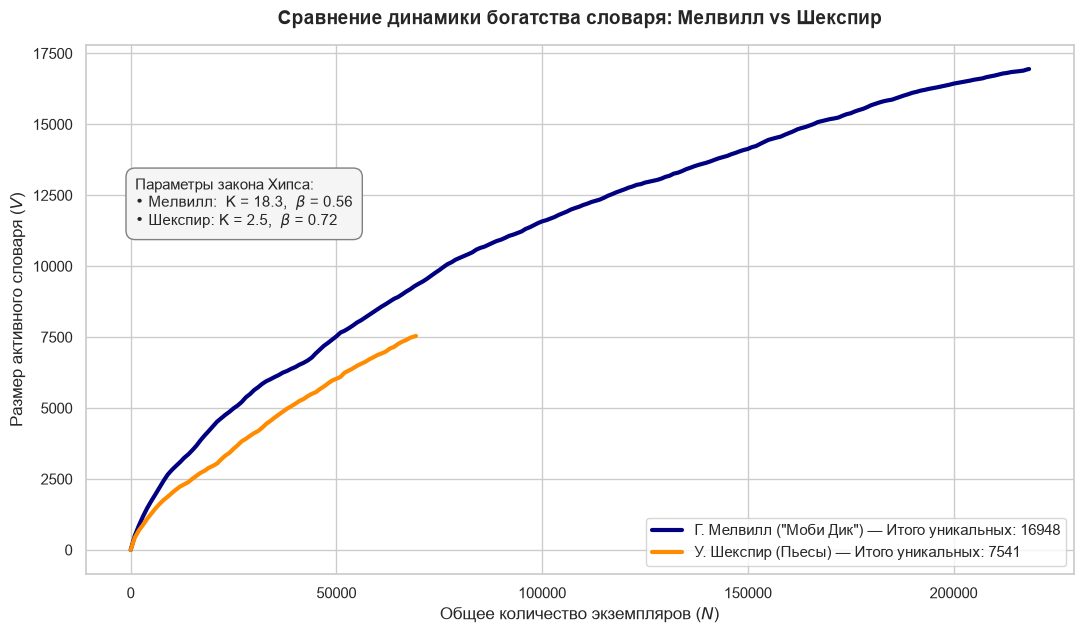

In [52]:
# Загрузка токенов произведений Уильяма Шекспира из корпуса NLTK
caesar_tokens = gutenberg.words('shakespeare-caesar.txt')
hamlet_tokens = gutenberg.words('shakespeare-hamlet.txt')
macbeth_tokens = gutenberg.words('shakespeare-macbeth.txt')

# Объединяем пьесы Шекспира в один массив токенов, очищая от пунктуации
shake_tokens = list(caesar_tokens) + list(hamlet_tokens) + list(macbeth_tokens)
shake_words = [word.lower() for word in shake_tokens if word.isalpha()]

# Собираем данные о росте словаря для Шекспира
shake_tokens_count, shake_vocab_size = calculate_heaps_data(shake_words, step=1000)

# Фигурируем график сравнения двух авторов
plt.figure(figsize=(11, 6.5))

plt.plot(tokens_count, vocab_size, color='navy', lw=3, 
         label=f'Г. Мелвилл ("Моби Дик") — Итого уникальных: {vocab_size[-1]}')
# ИСПРАВЛЕНО: Убрали вызов списка как функции и упростили выбор цвета
plt.plot(shake_tokens_count, shake_vocab_size, color='darkorange', lw=3, 
         label=f'У. Шекспир (Пьесы) — Итого уникальных: {shake_vocab_size[-1]}')

# Автоматически подбираем коэффициенты для Шекспира для вывода в текстовом аннотировании
popt_shake, _ = curve_fit(heaps_law_func, shake_tokens_count, shake_vocab_size, p0=[20, 0.5])

# ИСПРАВЛЕНО: Добавлены индексы [0] и [1] для popt_shake, так как это массив из двух параметров [K, beta]
comparison_text = (
    f"Параметры закона Хипса:\n"
    f"• Мелвилл:  K = {fitted_k:.1f},  $\\beta$ = {fitted_beta:.2f}\n"
    f"• Шекспир: K = {popt_shake[0]:.1f},  $\\beta$ = {popt_shake[1]:.2f}"
)
plt.gca().text(0.05, 0.75, comparison_text, transform=plt.gca().transAxes, fontsize=11,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.6', facecolor='whitesmoke', edgecolor='gray'))

plt.title('Сравнение динамики богатства словаря: Мелвилл vs Шекспир', fontsize=14, pad=15, weight='bold')
plt.xlabel('Общее количество экземпляров ($N$)', fontsize=12)
plt.ylabel('Размер активного словаря ($V$)', fontsize=12)
plt.legend(fontsize=11, loc='lower right', frameon=True)

plt.tight_layout()
plt.show()


## Битва реперов

Мы проверим закон Хипса ($V = K \cdot N^\beta$) на корпусах текстов двух артистов современности. Давайте смоделируем и сравним динамику роста словаря для Kanye West и Eminem.

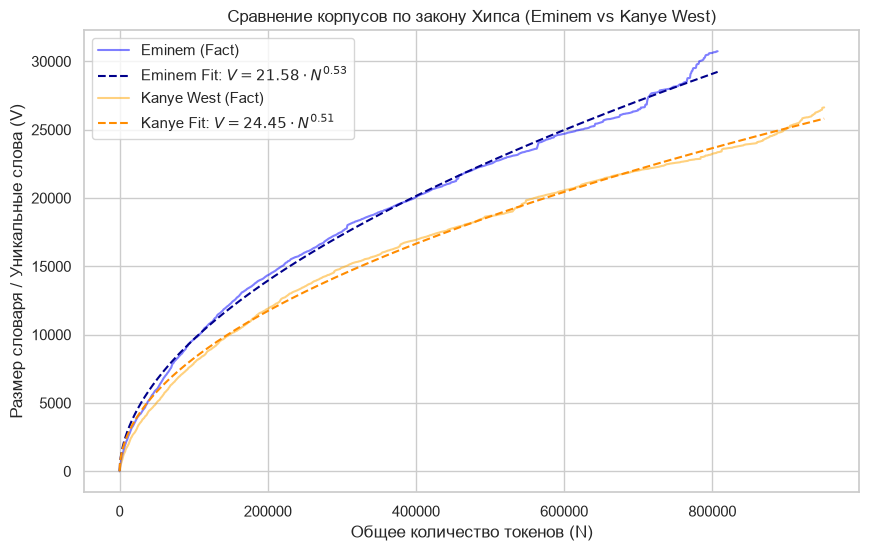

Исполнитель  Всего токенов (N)  Всего уникальных (V)  Параметр K  Параметр beta (β)
     Eminem             807145                 30737   21.575734           0.530197
 Kanye West             950958                 26629   24.453566           0.505742


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re

from datasets import Dataset, DatasetDict

def load_dataset(file_name):
    # 1. Читаем файл встроенными средствами Python
    with open(file_name, "r", encoding="utf-8") as f:
        raw_data = json.load(f)
        
    # 2. Создаем структуру столбцов вручную (избавляемся от сырого списка строк)
    formatted_data = {"text": raw_data['train']}

    # 3. Собираем DatasetDict (чтобы сохранить разделение на 'train')
    dataset = DatasetDict({
        "train": Dataset.from_dict(formatted_data)
    })
    return dataset


dataset_eminem = load_dataset("input/eminem.json")
dataset_kanye = load_dataset("input/kanye.json")

def tokenize_corpus(dataset):
    # Объединяем все тексты в одну строку, приводим к нижнему регистру и выделяем слова
    full_text = " ".join(dataset['train']['text']).lower()
    words = re.findall(r'\b[a-zа-я0-9\']+\b', full_text)
    return words

def analyze_heaps(words, label):
    N, V = calculate_heaps_data(words)
    # Подгонка параметров K и beta
    popt, _ = curve_fit(heaps_law_func, N, V, p0=[10, 0.5], bounds=(0, [np.inf, 1.0]))
    K, beta = popt
    return N, V, K, beta

# Токенизация
words_eminem = tokenize_corpus(dataset_eminem)
words_kanye = tokenize_corpus(dataset_kanye)

# Вычисление параметров
N_em, V_em, K_em, beta_em = analyze_heaps(words_eminem, "Eminem")
N_ka, V_ka, K_ka, beta_ka = analyze_heaps(words_kanye, "Kanye")

# 4. Визуализация результатов
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Кривая Эминема
plt.plot(N_em, V_em, label=f'Eminem (Fact)', color='blue', alpha=0.5)
plt.plot(N_em, heaps_law(N_em, K_em, beta_em), '--', color='darkblue', 
         label=f'Eminem Fit: $V = {K_em:.2f} \cdot N^{{{beta_em:.2f}}}$')

# Кривая Канье
plt.plot(N_ka, V_ka, label=f'Kanye West (Fact)', color='orange', alpha=0.5)
plt.plot(N_ka, heaps_law(N_ka, K_ka, beta_ka), '--', color='darkorange', 
         label=f'Kanye Fit: $V = {K_ka:.2f} \cdot N^{{{beta_ka:.2f}}}$')

plt.title("Сравнение корпусов по закону Хипса (Eminem vs Kanye West)")
plt.xlabel("Общее количество токенов (N)")
plt.ylabel("Размер словаря / Уникальные слова (V)")
plt.legend()
plt.show()

# Вывод сводной таблицы в консоль
df_results = pd.DataFrame({
    "Исполнитель": ["Eminem", "Kanye West"],
    "Всего токенов (N)": [len(words_eminem), len(words_kanye)],
    "Всего уникальных (V)": [len(set(words_eminem)), len(set(words_kanye))],
    "Параметр K": [K_em, K_ka],
    "Параметр beta (β)": [beta_em, beta_ka]
})
print(df_results.to_string(index=False))